Task 3: Exploratory Data Analysis (EDA)
By: Shahin
Dataset: Titanic (Kaggle)
Goal: Analyze the dataset to find patterns and trends

In [3]:
import pandas as pd
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
print(" Dataset loaded successfully!")
print(titanic.shape)

 Dataset loaded successfully!
(891, 12)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic.drop(columns=['Cabin'], inplace=True)
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})
titanic['Embarked'] = titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
titanic.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

print("Dataset ready for analysis!")
print("Size:", titanic.shape)
print(titanic.head())

Dataset ready for analysis!
Size: (891, 8)
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0


In [6]:
print("📊 Basic Statistics:")
print(titanic.describe())
survived = titanic['Survived'].sum()
not_survived = (titanic['Survived'] == 0).sum()
rate = titanic['Survived'].mean() * 100

print(f"\nTotal Survived: {survived}")
print(f"Total Not Survived: {not_survived}")
print(f"Overall Survival Rate: {rate:.2f}%")

📊 Basic Statistics:
         Survived      Pclass         Sex         Age       SibSp       Parch  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642    0.352413   29.361582    0.523008    0.381594   
std      0.486592    0.836071    0.477990   13.019697    1.102743    0.806057   
min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
25%      0.000000    2.000000    0.000000   22.000000    0.000000    0.000000   
50%      0.000000    3.000000    0.000000   28.000000    0.000000    0.000000   
75%      1.000000    3.000000    1.000000   35.000000    1.000000    0.000000   
max      1.000000    3.000000    1.000000   80.000000    8.000000    6.000000   

             Fare    Embarked  
count  891.000000  891.000000  
mean    32.204208    0.361392  
std     49.693429    0.635673  
min      0.000000    0.000000  
25%      7.910400    0.000000  
50%     14.454200    0.000000  
75%     31.000000    1.000

In [7]:
gender_survival = titanic.groupby('Sex')['Survived'].mean() * 100
print("Survival Rate by Gender:")
print(f"Male (0): {gender_survival[0]:.2f}%")
print(f"Female (1): {gender_survival[1]:.2f}%")

Survival Rate by Gender:
Male (0): 18.89%
Female (1): 74.20%


In [8]:
class_survival = titanic.groupby('Pclass')['Survived'].mean() * 100
print("Survival Rate by Passenger Class:")
print(f"1st Class: {class_survival[1]:.2f}%")
print(f"2nd Class: {class_survival[2]:.2f}%")
print(f"3rd Class: {class_survival[3]:.2f}%")

Survival Rate by Passenger Class:
1st Class: 62.96%
2nd Class: 47.28%
3rd Class: 24.24%


In [9]:
print("Checking for Outliers:")
print(f"Oldest passenger: {titanic['Age'].max()} years")
print(f"Youngest passenger: {titanic['Age'].min()} years")
print(f"Most expensive ticket: ${titanic['Fare'].max():.2f}")
print(f"Cheapest ticket: ${titanic['Fare'].min():.2f}")
print(f"Largest family size: {titanic['SibSp'].max()}")

Checking for Outliers:
Oldest passenger: 80.0 years
Youngest passenger: 0.42 years
Most expensive ticket: $512.33
Cheapest ticket: $0.00
Largest family size: 8


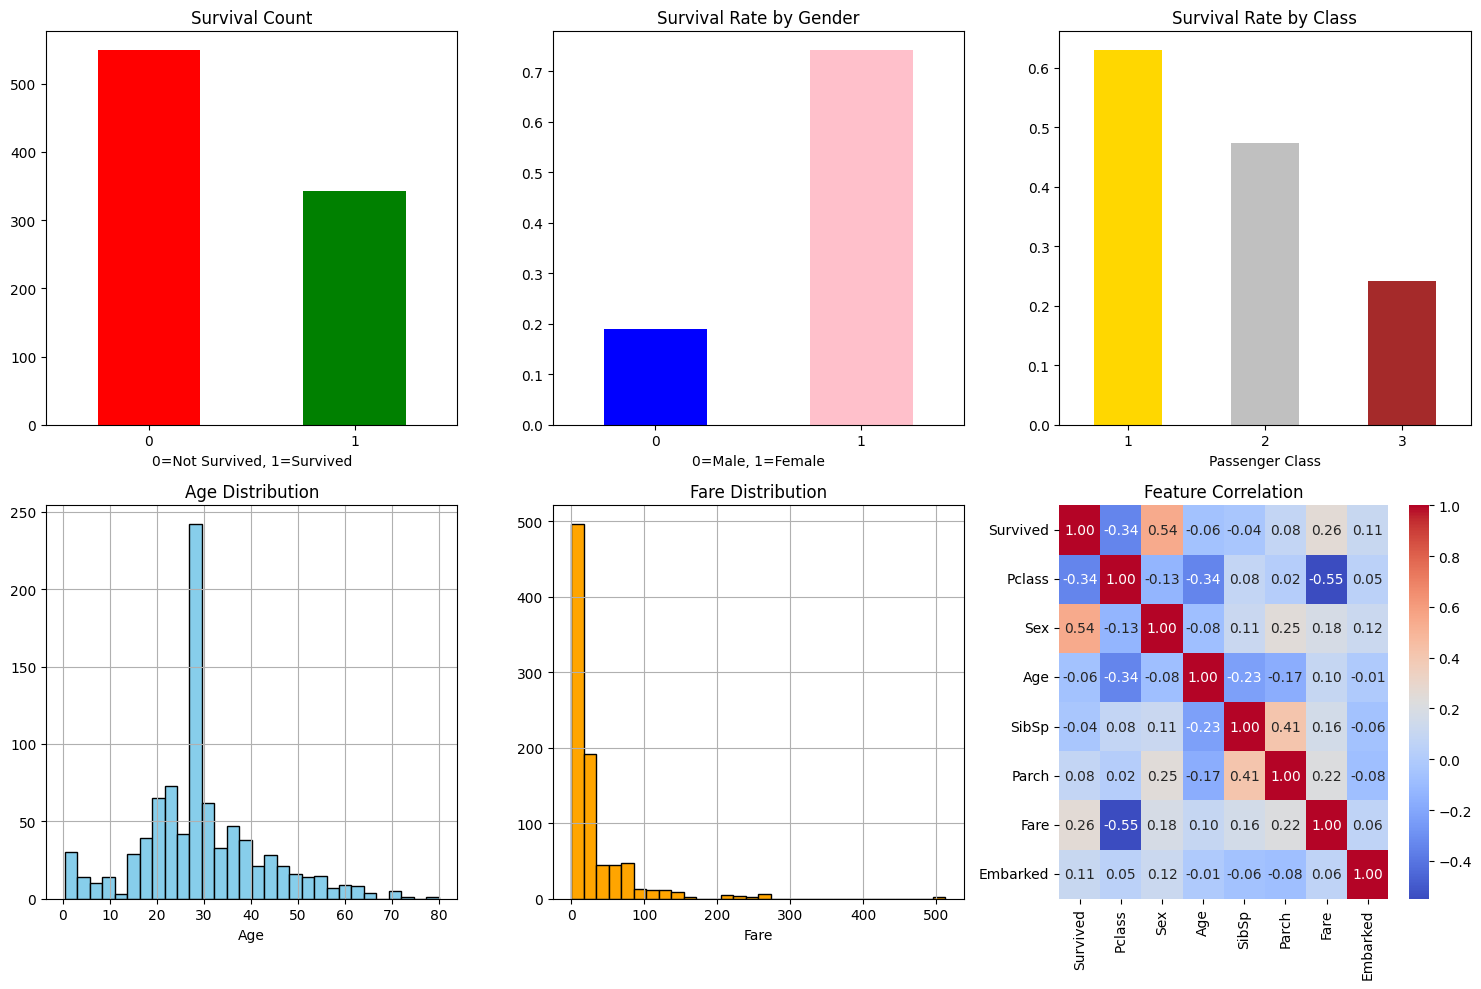

All charts created!


In [10]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
titanic['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count')
plt.xlabel('0=Not Survived, 1=Survived')
plt.xticks(rotation=0)
plt.subplot(2, 3, 2)
titanic.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['blue', 'pink'])
plt.title('Survival Rate by Gender')
plt.xlabel('0=Male, 1=Female')
plt.xticks(rotation=0)
plt.subplot(2, 3, 3)
titanic.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Survival Rate by Class')
plt.xlabel('Passenger Class')
plt.xticks(rotation=0)
plt.subplot(2, 3, 4)
titanic['Age'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.subplot(2, 3, 5)
titanic['Fare'].hist(bins=30, color='orange', edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.subplot(2, 3, 6)
sns.heatmap(titanic.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()
print("All charts created!")

In [11]:
print("=" * 50)
print("MY EDA FINDINGS - Shahin")
print("=" * 50)

print("\n📌 Dataset:")
print(f"  Total Passengers: {len(titanic)}")
print(f"  Total Features: {titanic.shape[1]}")

print("\n📌 Survival:")
print(f"  Overall: {titanic['Survived'].mean()*100:.2f}%")
print(f"  Female: {titanic[titanic['Sex']==1]['Survived'].mean()*100:.2f}%")
print(f"  Male: {titanic[titanic['Sex']==0]['Survived'].mean()*100:.2f}%")

print("\n📌 By Class:")
print(f"  1st Class: {titanic[titanic['Pclass']==1]['Survived'].mean()*100:.2f}%")
print(f"  2nd Class: {titanic[titanic['Pclass']==2]['Survived'].mean()*100:.2f}%")
print(f"  3rd Class: {titanic[titanic['Pclass']==3]['Survived'].mean()*100:.2f}%")

print("\n📌 What I Found:")
print("  1. Women survived 4x more than men")
print("  2. 1st class had highest survival rate")
print("  3. Younger passengers survived slightly more")
print("  4. Higher ticket fare = better survival chance")
print("  5. Fare column has extreme outliers")

MY EDA FINDINGS - Shahin

📌 Dataset:
  Total Passengers: 891
  Total Features: 8

📌 Survival:
  Overall: 38.38%
  Female: 74.20%
  Male: 18.89%

📌 By Class:
  1st Class: 62.96%
  2nd Class: 47.28%
  3rd Class: 24.24%

📌 What I Found:
  1. Women survived 4x more than men
  2. 1st class had highest survival rate
  3. Younger passengers survived slightly more
  4. Higher ticket fare = better survival chance
  5. Fare column has extreme outliers


My Conclusions from EDA:

1. Gender was the most important factor - women were prioritized
2. Wealth (class and fare) played a big role in survival
3. Age had a small effect - younger passengers survived slightly more
4. The dataset has some outliers in Fare column
5. This analysis helped me understand the data before building my model